# Q3. Feature Engineering and Regression Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("q3_retail_promotions.csv")
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [4]:
df = df.sort_values("transaction_date")

X = df.drop(["items_sold", "transaction_date"], axis=1)
y = df["items_sold"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (960, 11)
Test shape: (240, 11)


A random split is inappropriate for time-ordered data because it can cause data leakage. Future records may enter the training set while older records are used for testing. In real business forecasting, the model is trained on past data and tested on future data, so a temporal split is more realistic.

In [5]:
categorical_features = ["promotion_type", "location_type", "store_size"]

numerical_features = [
    "store_id",
    "is_weekend",
    "is_festival",
    "competition_density",
    "year",
    "month",
    "day_of_week",
    "is_month_end"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [6]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression MAE:", linear_mae)

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395


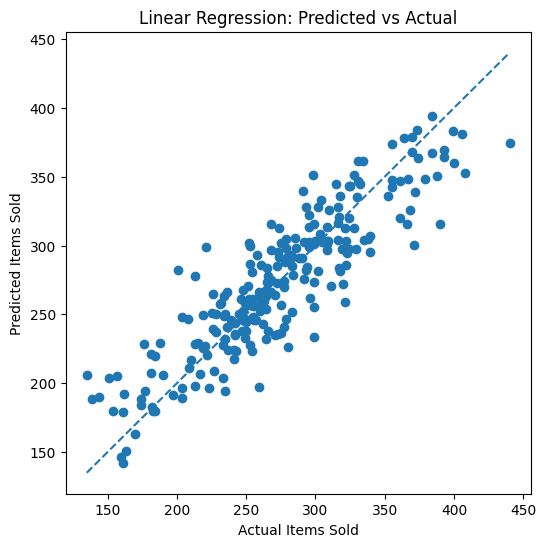

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, linear_pred)

min_value = min(y_test.min(), linear_pred.min())
max_value = max(y_test.max(), linear_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

In [8]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


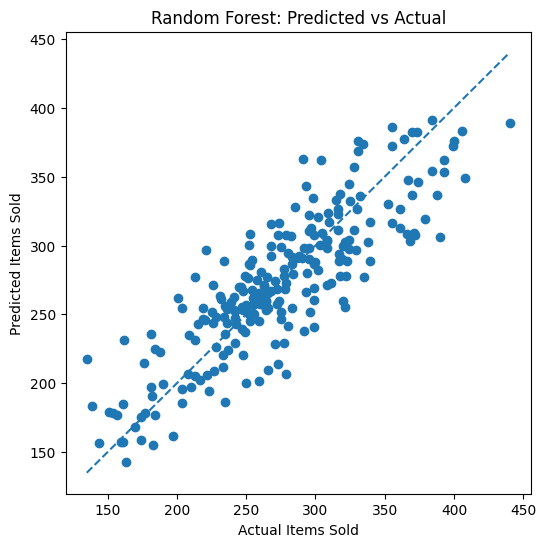

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)

min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

In [10]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
13,num__is_festival,0.173473
10,cat__store_size_small,0.167683
7,cat__location_type_urban,0.108378
17,num__day_of_week,0.086316
12,num__is_weekend,0.061208
11,num__store_id,0.054882
5,cat__location_type_rural,0.053794
8,cat__store_size_large,0.051113
14,num__competition_density,0.050805
16,num__month,0.037383


In [11]:
top_5_features = importance_df.head(5)

print("Top 5 most influential features:")
print(top_5_features)

Top 5 most influential features:
                     feature  importance
13          num__is_festival    0.173473
10     cat__store_size_small    0.167683
7   cat__location_type_urban    0.108378
17          num__day_of_week    0.086316
12           num__is_weekend    0.061208


The Random Forest feature importance values show which variables have the strongest influence on predicted items sold. The top five features are the most important drivers of sales prediction in this model. These may include promotion type, store characteristics, time-based features, or competition density depending on the dataset.